# Transfer Learning with EfficientNet

**Tracked with:** MLflow + DagsHub  
**Model:** EfficientNetB0 (ImageNet weights)  
**Dataset:** Food11 (11 food categories)

| Experiment | Strategy |
|---|---|
| 1 | Feature Extraction — frozen base, head only |
| 2 | Fine-Tuning — unfreeze last N layers |
| 3 | Gradual Unfreezing | Unfreeze one block at a time per phase |
| 4 | Layer-wise LR Decay | Each block gets a decayed learning rate |


## 0. Install Dependencies

In [1]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.

## 1. Imports & Configuration

In [2]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import mlflow
import mlflow.keras

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
SEED        = 42
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS_FE   = 30      # Feature Extraction
EPOCHS_FT   = 15      # Fine-Tuning
LR_FE       = 1e-3
LR_FT       = 1e-5
UNFREEZE_N  = 20      # last N base-model layers to unfreeze
AUTOTUNE    = tf.data.AUTOTUNE
EPOCHS_GU_PHASE   = 5       # Gradual Unfreezing — epochs per phase
EPOCHS_LWLR       = 15      # Layer-wise LR Decay

tf.keras.utils.set_random_seed(SEED)


LR_FE    = 1e-3
LR_FT    = 1e-5
LR_LWLR  = 1e-4             # base LR for deepest unfrozen block




## 2. DagsHub & MLflow Setup



In [4]:
DAGSHUB_USERNAME = "MoojProject"
DAGSHUB_REPO = "efficientnet-food"
DAGSHUB_TOKEN = "13bf92b9dcd3fdaed9511417548d2c7193c649dc"

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

TRACKING_URI = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("food11-efficientnet")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: https://dagshub.com/MoojProject/efficientnet-food.mlflow


## 3. Data Download & Extraction

In [5]:
def download_and_extract():
    if "dataset" in os.listdir():
        print("Dataset already exists — skipping download.")
        return
    print("Downloading Food11 dataset from Kaggle...")
    !wget -q -O food-data.zip \
        https://www.kaggle.com/api/v1/datasets/download/trolukovich/food11-image-dataset
    os.makedirs("dataset", exist_ok=True)
    !unzip -q food-data.zip -d dataset
    print("Done.")

download_and_extract()

Done.


## 4. Dataset Preprocessing

In [6]:
image_paths = glob.glob("dataset/*/*/*.jpg")
string_labels = [p.split("/")[-2] for p in image_paths]

df = pd.DataFrame({
    "image_path": image_paths,
    "label": string_labels})

print(f"Total images : {len(df):,}")
print(f"Classes ({len(df['label'].unique())}):", sorted(df['label'].unique()))
print(df.head())
print(df["label"].value_counts())

Total images : 16,643
Classes (11): ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
                     image_path label
0  dataset/training/Egg/707.jpg   Egg
1  dataset/training/Egg/411.jpg   Egg
2   dataset/training/Egg/77.jpg   Egg
3   dataset/training/Egg/12.jpg   Egg
4  dataset/training/Egg/641.jpg   Egg
label
Soup               2500
Dessert            2500
Meat               2206
Bread              1724
Egg                1648
Seafood            1505
Fried food         1461
Vegetable-Fruit    1172
Noodles-Pasta       734
Dairy product       721
Rice                472
Name: count, dtype: int64


In [7]:
class_names    = sorted(df["label"].unique())
NUM_CLASSES    = len(class_names)
class_to_index = {name: idx for idx, name in enumerate(class_names)}
index_to_class = {idx: name for name, idx in class_to_index.items()}

df["label_int"] = df["label"].map(class_to_index)
print("Number of classes:", NUM_CLASSES)
print(class_to_index)

Number of classes: 11
{'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}


In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train : ",len(train_df))
print("Val   : ",len(val_df))
print("Test  : ",len(test_df))

Train :  13314
Val   :  1664
Test  :  1665


In [9]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)   # 0, 255
    label = tf.cast(label, tf.int32)
    return image, label

#  Augmentation training
data_aug = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
], name="augmentation")


def make_dataset(dataframe, training=False):
    paths  = dataframe["image_path"].values
    labels = dataframe["label_int"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_aug(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print("Train batches:", len(train_ds))
print("Val   batches:", len(val_ds))
print("Test  batches:", len(test_ds))

Train batches: 417
Val   batches: 52
Test  batches: 53


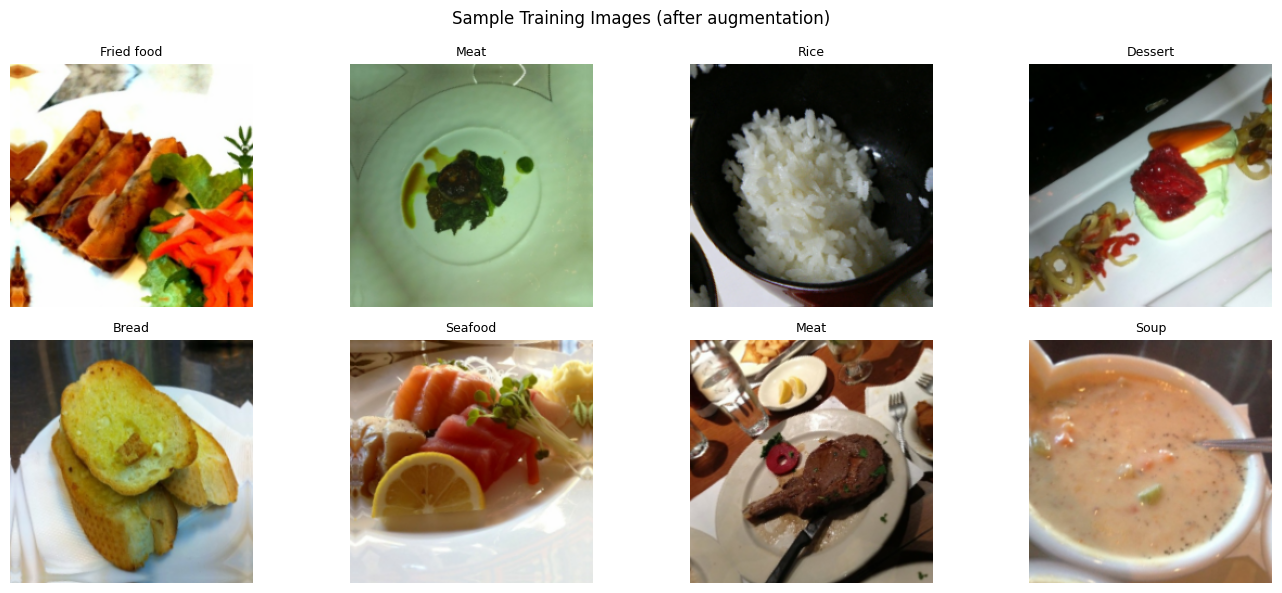

In [10]:
images_sample, labels_sample = next(iter(train_ds))

plt.figure(figsize=(14, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    img = images_sample[i].numpy().astype("uint8")
    plt.imshow(img)
    plt.title(index_to_class[int(labels_sample[i])], fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Training Images (after augmentation)", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Shared fuctuin

In [11]:
os.makedirs("models",  exist_ok=True)
os.makedirs("results", exist_ok=True)
# هذي الملفات بس عشان احفظ كل المودل والنتايج

In [12]:
def plot_history(history, title_prefix):
    acc     = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss    = history.history["loss"]
    val_loss= history.history["val_loss"]
    epochs  = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(epochs, acc,     label="Train")
    axes[0].plot(epochs, val_acc, label="Validation")
    axes[0].set_title(f"{title_prefix} — Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(True)

    # Loss
    axes[1].plot(epochs, loss,     label="Train")
    axes[1].plot(epochs, val_loss, label="Validation")
    axes[1].set_title(f"{title_prefix} — Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    save_path = f"results/{title_prefix.lower().replace(' ', '_')}_curves.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    return save_path


def evaluate_and_report(model, dataset, label, class_names):

    loss, acc = model.evaluate(dataset, verbose=0)
    print(f"[{label}]  Test Loss: {loss:.4f}  |  Test Accuracy: {acc:.4f}")

    y_true, y_pred = [], []
    for imgs, lbls in dataset:
        preds = np.argmax(model.predict(imgs, verbose=0), axis=1)
        y_true.extend(lbls.numpy())
        y_pred.extend(preds)

    report = classification_report(y_true, y_pred, target_names=class_names)
    print(report)

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=class_names,
        ax=ax, xticks_rotation=45
    )
    ax.set_title(f"{label} — Confusion Matrix")
    plt.tight_layout()
    cm_path = f"results/{label.lower().replace(' ', '_')}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()

    # Save report text
    report_path = f"results/{label.lower().replace(' ', '_')}_report.txt"
    with open(report_path, "w") as f:
        f.write(report)

    return {
        "test_loss": loss,
        "test_acc":  acc,
        "report_path": report_path,
        "cm_path":     cm_path,
    }


def log_epoch_metrics(history, run_id=None):

    for step, (ta, va, tl, vl) in enumerate(zip(
        history.history["accuracy"],
        history.history["val_accuracy"],
        history.history["loss"],
        history.history["val_loss"],
    )):
        mlflow.log_metrics({
            "train_accuracy": ta,
            "val_accuracy":   va,
            "train_loss":     tl,
            "val_loss":       vl,
        }, step=step)

---
## 6. Experiment 1 — Feature Extraction

 Freeze the entire EfficientNetB0 bas train only the clasification head



In [13]:
def build_feature_extraction_model(num_classes):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3)
    )
    base.trainable = False   # freeze entire base

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="EfficientNetB0_FeatureExtraction")
    return model, base

fe_model, fe_base = build_feature_extraction_model(NUM_CLASSES)



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
trainable     = sum(1 for w in fe_model.trainable_weights)
non_trainable = sum(1 for w in fe_model.non_trainable_weights)
print(f"Trainable params    : {trainable:,}")
print(f"Non-trainable params: {non_trainable:,}")

Trainable params    : 4
Non-trainable params: 314


In [15]:
fe_model.summary()

Model: "EfficientNetB0_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,782 (15.52 MB)

 Trainable params: 16,651 (65.04 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [16]:
fe_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Callbacks



In [17]:
fe_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="models/feature_extraction_best.keras",
        monitor="val_accuracy",
        save_best_only=True, verbose=1
    ),
]

## Train + MLflow tracking


Epoch 1/30
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.6027 - loss: 1.2849
Epoch 1: val_accuracy improved from None to 0.86899, saving model to models/feature_extraction_best.keras

Epoch 1: finished saving model to models/feature_extraction_best.keras
417/417 ━━━━━━━━━━━━━━━━━━━━ 206s 420ms/step - accuracy: 0.7165 - loss: 0.8983 - val_accuracy: 0.8690 - val_loss: 0.3761 - learning_rate: 0.0010
Epoch 2/30
416/417 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.8201 - loss: 0.5671
Epoch 2: val_accuracy improved from 0.86899 to 0.89303, saving model to models/feature_extraction_best.keras

Epoch 2: finished saving model to models/feature_extraction_best.keras
417/417 ━━━━━━━━━━━━━━━━━━━━ 168s 402ms/step - accuracy: 0.8213 - loss: 0.5614 - val_accuracy: 0.8930 - val_loss: 0.3380 - learning_rate: 0.0010
Epoch 3/30
416/417 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8407 - loss: 0.4910
Epoch 3: val_accuracy improved from 0.89303 to 0.89543, saving model to models/feature_

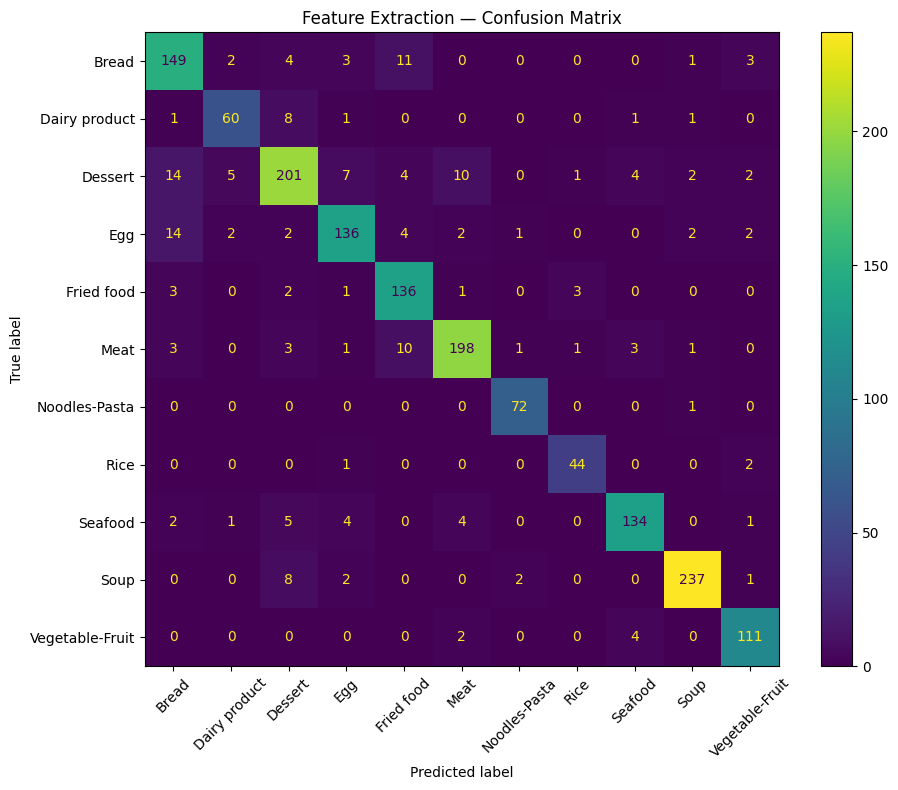

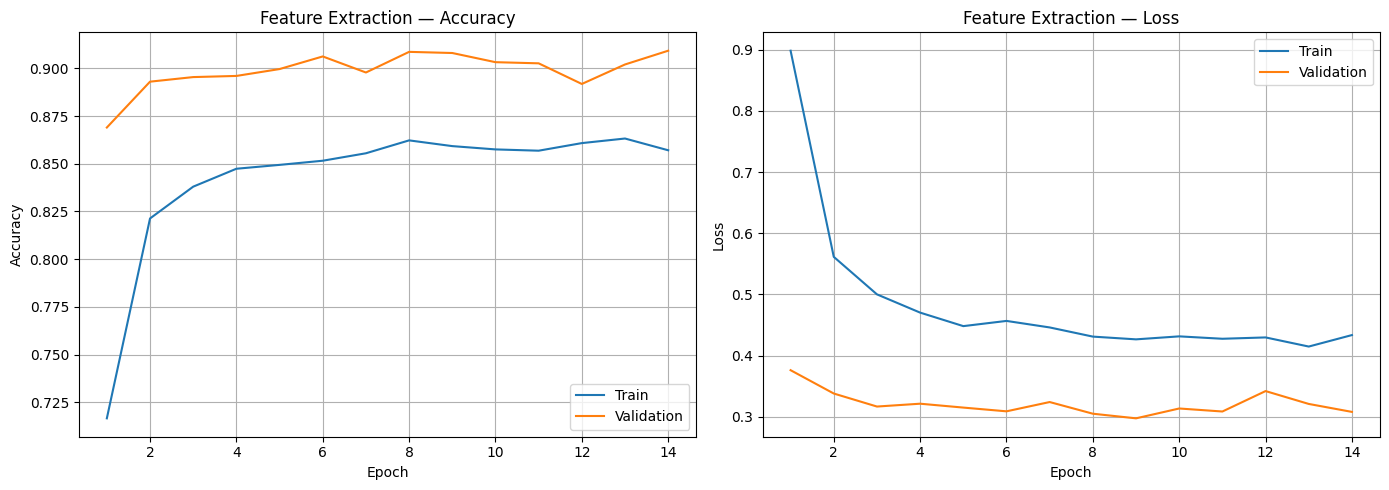


MLflow Run ID: 738650dbd2934900921f29dd14853c2c
🏃 View run EfficientNetB0_FeatureExtraction at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2/runs/738650dbd2934900921f29dd14853c2c
🧪 View experiment at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2


In [ ]:
#Train + MLflow tracking
with mlflow.start_run(run_name="EfficientNetB0_FeatureExtraction") as run_fe:

    mlflow.log_params({
        "experiment"  : "feature_extraction",
        "base_model"  : "EfficientNetB0",
        "img_size"    : IMG_SIZE[0],
        "batch_size"  : BATCH_SIZE,
        "epochs"      : EPOCHS_FE,
        "learning_rate": LR_FE,
        "frozen_layers": "all",
    })

    history_fe = fe_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FE,
        callbacks=fe_callbacks,
    )

    #  epoch metrics
    log_epoch_metrics(history_fe)

    #  Test evaluation
    results_fe = evaluate_and_report(
        fe_model, test_ds,
        label="Feature Extraction",
        class_names=class_names
    )
    mlflow.log_metrics({
        "test_accuracy": results_fe["test_acc"],
        "test_loss":     results_fe["test_loss"],
    })

    # Plots & Artifacts
    curve_path = plot_history(history_fe, "Feature Extraction")
    mlflow.log_artifact(curve_path)
    mlflow.log_artifact(results_fe["report_path"])
    mlflow.log_artifact(results_fe["cm_path"])
    mlflow.log_artifact("models/feature_extraction_best.keras")

    print(f"\nMLflow Run ID: {run_fe.info.run_id}")

### Experiment 1  

| Metric | Value |
|--------|-------|
| Test Accuracy | **88.77%** |
| Test Loss | **0.3512** |


- The model achieved **88.77% test accuracy**, which shows that the frozen base worked well as a strong fixed feature extractor for Food11.
- Training converged relatively quickly and validation performance remained stable across epochs.
- Overfitting was limited because the pretrained backbone weights were not updated.
- Some classes such as **Soup, Noodles-Pasta, Rice, and Vegetable-Fruit** achieved very strong results, while classes like **Bread, Dessert, and Egg** showed relatively more confusion.


## 7. Experiment 2 — Fine-Tuning

Start from the best Feature Extraction checkpoint,  
then unfreeze the last UNFREEZE_N layers of the base and train with a very small learning rate.



In [19]:
#  Load best model
ft_model = keras.models.load_model("models/feature_extraction_best-2.keras")

ft_base = None
for layer in ft_model.layers:
    if isinstance(layer, keras.Model):
        ft_base = layer
        break

print("Base model:", ft_base.name)
print("Total layers in base:", len(ft_base.layers))

Base model: efficientnetb0
Total layers in base: 238


In [20]:
ft_base.trainable = True

# First freeze everything
for layer in ft_base.layers:
    layer.trainable = False

# Then unfreeze the last N layers
for layer in ft_base.layers[-UNFREEZE_N:]:
    if not isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = True

trainable_now     = sum(1 for l in ft_base.layers if l.trainable)
non_trainable_now = len(ft_base.layers) - trainable_now

print(f"Trainable base layers    : {trainable_now}")
print(f"Non-trainable base layers: {non_trainable_now}")

Trainable base layers    : 15
Non-trainable base layers: 223


### Compile with a lower LR to prevent large weight updates


In [21]:
ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
ft_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="models/fine_tuned_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
]

### Train + MLflow tracking


Epoch 1/15
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.8697 - loss: 0.4028
Epoch 1: val_accuracy improved from None to 0.91286, saving model to models/fine_tuned_best.keras

Epoch 1: finished saving model to models/fine_tuned_best.keras
417/417 ━━━━━━━━━━━━━━━━━━━━ 229s 463ms/step - accuracy: 0.8689 - loss: 0.3922 - val_accuracy: 0.9129 - val_loss: 0.2982 - learning_rate: 1.0000e-05
Epoch 2/15
416/417 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8759 - loss: 0.3779
Epoch 2: val_accuracy improved from 0.91286 to 0.91647, saving model to models/fine_tuned_best.keras

Epoch 2: finished saving model to models/fine_tuned_best.keras
417/417 ━━━━━━━━━━━━━━━━━━━━ 165s 395ms/step - accuracy: 0.8796 - loss: 0.3676 - val_accuracy: 0.9165 - val_loss: 0.2931 - learning_rate: 1.0000e-05
Epoch 3/15
416/417 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8841 - loss: 0.3451
Epoch 3: val_accuracy did not improve from 0.91647
417/417 ━━━━━━━━━━━━━━━━━━━━ 163s 391ms/step - accuracy: 0.8

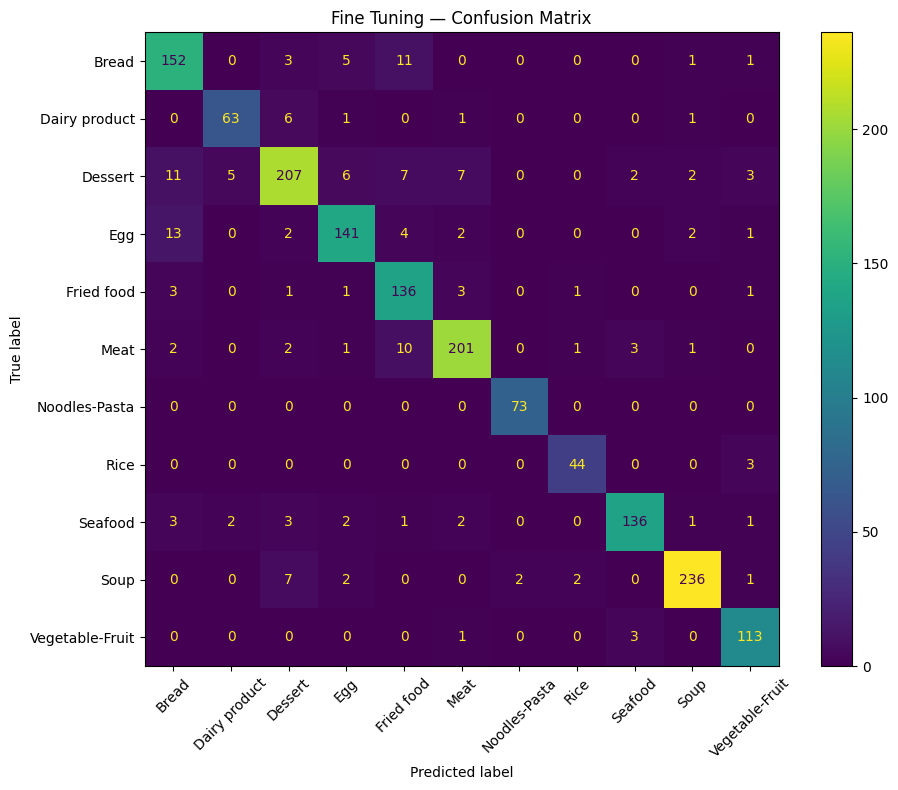

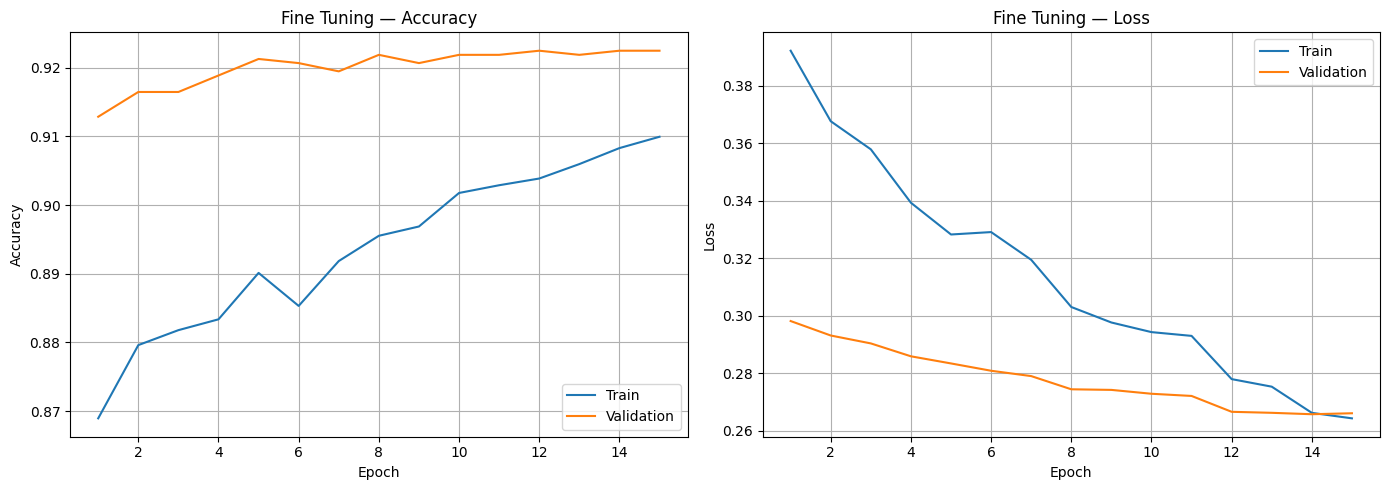


MLflow Run ID: 01f9a58859e841e39d5a38c125efc377
🏃 View run EfficientNetB0_FineTuning at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2/runs/01f9a58859e841e39d5a38c125efc377
🧪 View experiment at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2


In [ ]:
with mlflow.start_run(run_name="EfficientNetB0_FineTuning") as run_ft:

    mlflow.log_params({
        "experiment"    : "fine_tuning",
        "base_model"    : "EfficientNetB0",
        "img_size"      : IMG_SIZE[0],
        "batch_size"    : BATCH_SIZE,
        "epochs"        : EPOCHS_FT,
        "learning_rate" : LR_FT,
        "unfreeze_last_n": UNFREEZE_N,
    })

    history_ft = ft_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FT,
        callbacks=ft_callbacks,
    )

    log_epoch_metrics(history_ft)

    results_ft = evaluate_and_report(
        ft_model, test_ds,
        label="Fine Tuning",
        class_names=class_names
    )
    mlflow.log_metrics({
        "test_accuracy": results_ft["test_acc"],
        "test_loss":     results_ft["test_loss"],
    })

    curve_path_ft = plot_history(history_ft, "Fine Tuning")
    mlflow.log_artifact(curve_path_ft)
    mlflow.log_artifact(results_ft["report_path"])
    mlflow.log_artifact(results_ft["cm_path"])
    mlflow.log_artifact("models/fine_tuned_best.keras")

    print(f"\nMLflow Run ID: {run_ft.info.run_id}")

###  Experiment 2


| Metric | Value |
|--------|-------|
| Test Accuracy | **90.21%** |
| Test Loss | **0.3110** |

**Analysis:**
- Unfreezing the last 20 layers enabled the model to adapt pretrained ImageNet features more closely to the Food11 dataset.
- A very low learning rate (**1e-5**) was used to preserve pretrained knowledge and support stable fine-tuning.
- Fine-tuning outperformed feature extraction, improving both test accuracy and test loss.
- The training and validation curves suggest good convergence with no major overfitting.



---
## Experiment 2 — Gradual Unfreezing

Start from the Feature Extraction model.  
Unfreeze one EfficientNet **block** at a time across multiple training phases.  
Each phase trains for `EPOCHS_GU_PHASE` epochs, then the next block is unlocked.





In [23]:
gu_model = keras.models.load_model("models/feature_extraction_best-2.keras")
gu_base  = next(l for l in gu_model.layers if isinstance(l, keras.Model))

block_prefixes = []
seen = set()
for layer in reversed(gu_base.layers):
    name = layer.name
    prefix = "_".join(name.split("_")[:2]) if "_" in name else name
    if prefix not in seen:
        seen.add(prefix)
        block_prefixes.append(prefix)

# Show first 10 for reference
print("Blocks (deepest first):", block_prefixes[:10])

Blocks (deepest first): ['top_activation', 'top_bn', 'top_conv', 'block7a_project', 'block7a_se', 'block7a_activation', 'block7a_bn', 'block7a_dwconv', 'block7a_expand', 'block6d_add']


In [24]:
# block groups to unfreeze phase by phase
# 4 phases: top layers, block7, block6, block5
UNFREEZE_PHASES = [
    ["top"],            # Phase 1: stem + top conv
    ["block7"],         # Phase 2: last MBConv block
    ["block6"],         # Phase 3
    ["block5"],         # Phase 4
]

def unfreeze_blocks(base, keywords):

    newly_unfrozen = 0
    for layer in base.layers:
        if any(kw in layer.name for kw in keywords):
            if not isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = True
                newly_unfrozen += 1
    return newly_unfrozen

# Start fully frozen
gu_base.trainable = True
for layer in gu_base.layers:
    layer.trainable = False

print("All base layers frozen. Starting gradual unfreezing...")

All base layers frozen. Starting gradual unfreezing...



── Phase 1: unlocked '['top']' (+2 layers | total trainable: 2) ──
Epoch 1/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 233s 486ms/step - accuracy: 0.8638 - loss: 0.3996 - val_accuracy: 0.9111 - val_loss: 0.3012
Epoch 2/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 201s 483ms/step - accuracy: 0.8770 - loss: 0.3723 - val_accuracy: 0.9123 - val_loss: 0.2973
Epoch 3/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 154s 369ms/step - accuracy: 0.8764 - loss: 0.3736 - val_accuracy: 0.9117 - val_loss: 0.2958
Epoch 4/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 149s 357ms/step - accuracy: 0.8766 - loss: 0.3675 - val_accuracy: 0.9141 - val_loss: 0.2941
Epoch 5/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 150s 359ms/step - accuracy: 0.8804 - loss: 0.3655 - val_accuracy: 0.9165 - val_loss: 0.2927
Restoring model weights from the end of the best epoch: 5.

── Phase 2: unlocked '['block7']' (+10 layers | total trainable: 12) ──
Epoch 1/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 192s 404ms/step - accuracy: 0.8743 - loss: 0.3637 - val_accuracy: 0.9153 - val_loss: 0.2892
Epoch 2/5
417/

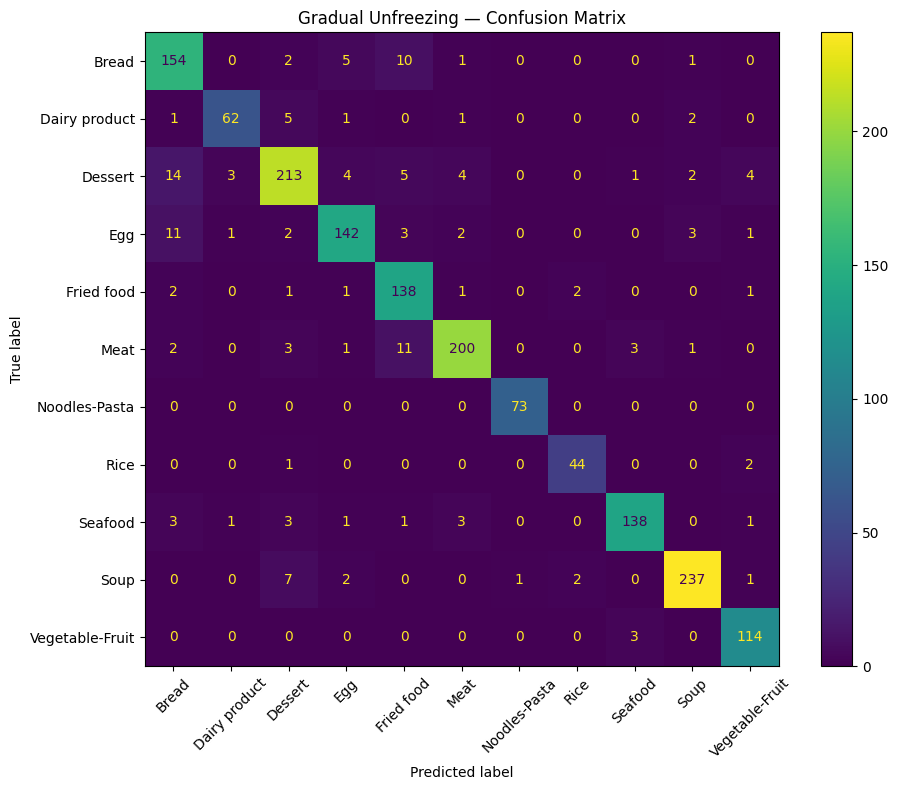

Run ID: d872f92b0a724c36a8431d74eab4a0cb
🏃 View run Exp3_GradualUnfreezing at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2/runs/d872f92b0a724c36a8431d74eab4a0cb
🧪 View experiment at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2


In [ ]:
# Gradual Unfreezing training loop
# Reference: https://keras.io/api/callbacks/

all_history_gu = []

with mlflow.start_run(run_name="Exp3_GradualUnfreezing") as run_gu:
    mlflow.log_params({
        "experiment": "gradual_unfreezing",
        "base_model": "EfficientNetB0",
        "img_size": IMG_SIZE[0], "batch_size": BATCH_SIZE,
        "epochs_per_phase": EPOCHS_GU_PHASE,
        "num_phases": len(UNFREEZE_PHASES),
        "lr": LR_FT,
    })

    global_step = 0

    for phase_idx, keywords in enumerate(UNFREEZE_PHASES):
        n = unfreeze_blocks(gu_base, keywords)
        total_trainable = sum(1 for l in gu_base.layers if l.trainable)
        print(f"\n── Phase {phase_idx + 1}: unlocked '{keywords}' "
              f"(+{n} layers | total trainable: {total_trainable}) ──")

        mlflow.log_param(f"phase_{phase_idx+1}_keywords", str(keywords))
        mlflow.log_param(f"phase_{phase_idx+1}_trainable_layers", total_trainable)

        gu_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history_phase = gu_model.fit(
            train_ds, validation_data=val_ds,
            epochs=EPOCHS_GU_PHASE,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss", patience=3,
                    restore_best_weights=True, verbose=1),
                keras.callbacks.ModelCheckpoint(
                    filepath="models/exp3_gradual_unfreezing.keras",
                    monitor="val_accuracy", save_best_only=True, verbose=0),
            ]
        )
        all_history_gu.append(history_phase)

        # Log metrics with global step offset
        for local_step, (ta, va, tl, vl) in enumerate(zip(
            history_phase.history["accuracy"],
            history_phase.history["val_accuracy"],
            history_phase.history["loss"],
            history_phase.history["val_loss"],
        )):
            mlflow.log_metrics(
                {"train_accuracy": ta, "val_accuracy": va,
                 "train_loss": tl, "val_loss": vl},
                step=global_step
            )
            global_step += 1

    results_gu = evaluate_and_report(gu_model, test_ds, "Gradual Unfreezing", class_names)
    mlflow.log_metrics({"test_accuracy": results_gu["test_acc"],
                        "test_loss":     results_gu["test_loss"]})

    for path in [results_gu["report_path"], results_gu["cm_path"],
                 "models/exp3_gradual_unfreezing.keras"]:
        mlflow.log_artifact(path)
    print(f"Run ID: {run_gu.info.run_id}")

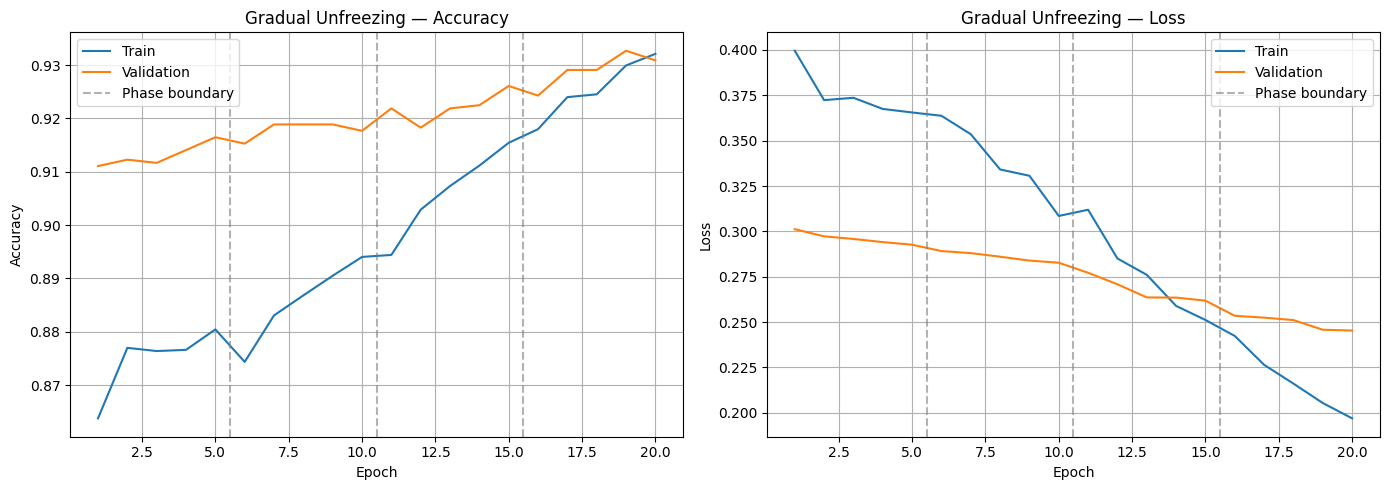

In [ ]:
# Plot all phases as a continuous curve
all_acc     = sum([h.history["accuracy"]     for h in all_history_gu], [])
all_val_acc = sum([h.history["val_accuracy"] for h in all_history_gu], [])
all_loss    = sum([h.history["loss"]         for h in all_history_gu], [])
all_val_loss= sum([h.history["val_loss"]     for h in all_history_gu], [])
epochs_gu   = range(1, len(all_acc) + 1)

# Mark phase boundaries
phase_boundaries = []
offset = 0
for h in all_history_gu[:-1]:
    offset += len(h.history["accuracy"])
    phase_boundaries.append(offset)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, train, val, ylabel in zip(
    axes,
    [all_acc, all_loss], [all_val_acc, all_val_loss],
    ["Accuracy", "Loss"]
):
    ax.plot(epochs_gu, train, label="Train")
    ax.plot(epochs_gu, val,   label="Validation")
    for pb in phase_boundaries:
        ax.axvline(x=pb + 0.5, color="gray", linestyle="--", alpha=0.6,
                   label="Phase boundary" if pb == phase_boundaries[0] else "")
    ax.set_title(f"Gradual Unfreezing — {ylabel}")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True)

plt.tight_layout()
gu_curve_path = "results/gradual_unfreezing_curves.png"
plt.savefig(gu_curve_path, dpi=150); plt.show()

### Experiment  

| Metric | Value |
|--------|-------|
| Test Accuracy | **90.99%** |
| Test Loss | **0.3005** |

**Analysis:**
- Gradual unfreezing improved the model by unlocking deeper layers step by step instead of fine-tuning a larger part of the backbone all
- This produced the best overall performance among the three experiments, reaching **90.99%** test accuracy with **0.3005** test loss.
- Training and validation curves show stable convergence with limited overfitting.
- Compared with feature extraction and standard fine-tuning, gradual unfreezing provided the strongest task specific adaptation.


---
## 9. Experiment 4 — Layer-wise Learning Rate Decay

Assign a **different learning rate to each layer block**.  
Deeper (later) blocks that need the most fine-tuning get a higher LR.  
Earlier blocks that hold general features get a much smaller LR.

**Decay formula:**
```
LR_block_i = LR_base × (decay_factor ^ i)
where i = 0 is the deepest unfrozen block
```

 Earlier layers already encode universal features (edges, textures).  
Using a tiny LR preserves them while allowing meaningful updates in deeper layers.


In [25]:

lwlr_model = keras.models.load_model("models/feature_extraction_best-2.keras")
lwlr_base  = next(l for l in lwlr_model.layers if isinstance(l, keras.Model))


LAYER_GROUPS = [
    ["top",    "block7"],   # Group 0 — deepest → highest LR
    ["block6", "block5"],   # Group 1
    ["block4", "block3"],   # Group 2
    ["block2", "block1"],   # Group 3 → lowest LR
]
LR_DECAY_FACTOR = 0.3       # each group gets LR × 0.3 relative to previous

# Unfreeze all
lwlr_base.trainable = True
for layer in lwlr_base.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

total_trainable = sum(1 for l in lwlr_base.layers if l.trainable)
print(f"Trainable base layers: {total_trainable}")

Trainable base layers: 189


In [26]:
DECAY = LR_DECAY_FACTOR
GROUP_LRS = [LR_LWLR * (DECAY ** i) for i in range(len(LAYER_GROUPS))]

print("Learning rate per group (deepest → shallowest):")
for i, (grp, lr) in enumerate(zip(LAYER_GROUPS, GROUP_LRS)):
    print(f"  Group {i}: {grp}  →  LR = {lr:.2e}")

Learning rate per group (deepest → shallowest):
  Group 0: ['top', 'block7']  →  LR = 1.00e-04
  Group 1: ['block6', 'block5']  →  LR = 3.00e-05
  Group 2: ['block4', 'block3']  →  LR = 9.00e-06
  Group 3: ['block2', 'block1']  →  LR = 2.70e-06



── Round 1: groups [0] active | LR=1.00e-04 | trainable=12 ──
Epoch 1/3
417/417 ━━━━━━━━━━━━━━━━━━━━ 219s 432ms/step - accuracy: 0.8737 - loss: 0.3884 - val_accuracy: 0.9195 - val_loss: 0.2802
Epoch 2/3
417/417 ━━━━━━━━━━━━━━━━━━━━ 154s 369ms/step - accuracy: 0.8970 - loss: 0.3070 - val_accuracy: 0.9159 - val_loss: 0.2765
Epoch 3/3
417/417 ━━━━━━━━━━━━━━━━━━━━ 201s 366ms/step - accuracy: 0.9142 - loss: 0.2575 - val_accuracy: 0.9213 - val_loss: 0.2647
Restoring model weights from the end of the best epoch: 3.

── Round 2: groups [0, 1] active | LR=3.00e-05 | trainable=93 ──
Epoch 1/3
417/417 ━━━━━━━━━━━━━━━━━━━━ 225s 454ms/step - accuracy: 0.9246 - loss: 0.2199 - val_accuracy: 0.9219 - val_loss: 0.2664
Epoch 2/3
417/417 ━━━━━━━━━━━━━━━━━━━━ 166s 398ms/step - accuracy: 0.9333 - loss: 0.1896 - val_accuracy: 0.9231 - val_loss: 0.2520
Epoch 3/3
417/417 ━━━━━━━━━━━━━━━━━━━━ 169s 405ms/step - accuracy: 0.9405 - loss: 0.1732 - val_accuracy: 0.9297 - val_loss: 0.2508
Restoring model weights fr

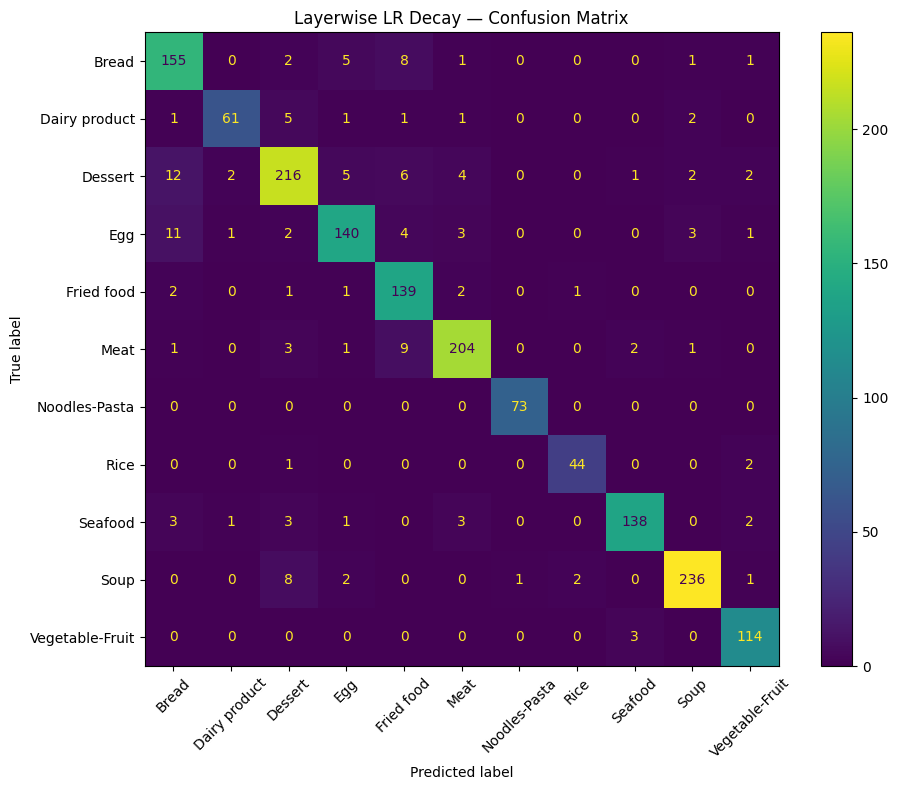

Run ID: 881af9a994ad427bbb63e56630201f28
🏃 View run Exp4_LayerwiseLRDecay at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2/runs/881af9a994ad427bbb63e56630201f28
🧪 View experiment at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2


In [27]:
all_history_lwlr = []

def set_trainable_groups(base, active_groups, all_groups):

    for layer in base.layers:
        layer.trainable = False
    for g_idx in active_groups:
        for keyword in all_groups[g_idx]:
            for layer in base.layers:
                if keyword in layer.name:
                    if not isinstance(layer, keras.layers.BatchNormalization):
                        layer.trainable = True

with mlflow.start_run(run_name="Exp4_LayerwiseLRDecay") as run_lwlr:
    mlflow.log_params({
        "experiment": "layerwise_lr_decay",
        "base_model": "EfficientNetB0",
        "img_size": IMG_SIZE[0], "batch_size": BATCH_SIZE,
        "epochs_per_round": EPOCHS_LWLR // len(LAYER_GROUPS),
        "base_lr": LR_LWLR, "decay_factor": LR_DECAY_FACTOR,
        "num_groups": len(LAYER_GROUPS),
    })

    global_step = 0
    epochs_per_round = max(EPOCHS_LWLR // len(LAYER_GROUPS), 3)

    for round_idx in range(len(LAYER_GROUPS)):
        active = list(range(round_idx + 1))
        set_trainable_groups(lwlr_base, active, LAYER_GROUPS)

        # Use the LR of the newly added (shallowest active) group
        current_lr = GROUP_LRS[round_idx]
        n_trainable = sum(1 for l in lwlr_base.layers if l.trainable)

        print(f"\n── Round {round_idx+1}: groups {active} active | "
              f"LR={current_lr:.2e} | trainable={n_trainable} ──")

        mlflow.log_param(f"round_{round_idx+1}_lr", current_lr)
        mlflow.log_param(f"round_{round_idx+1}_trainable", n_trainable)

        lwlr_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=current_lr),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history_round = lwlr_model.fit(
            train_ds, validation_data=val_ds,
            epochs=epochs_per_round,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss", patience=3,
                    restore_best_weights=True, verbose=1),
                keras.callbacks.ModelCheckpoint(
                    filepath="models/exp4_layerwise_lr.keras",
                    monitor="val_accuracy", save_best_only=True, verbose=0),
            ]
        )
        all_history_lwlr.append(history_round)

        for local_step, (ta, va, tl, vl) in enumerate(zip(
            history_round.history["accuracy"],
            history_round.history["val_accuracy"],
            history_round.history["loss"],
            history_round.history["val_loss"],
        )):
            mlflow.log_metrics(
                {"train_accuracy": ta, "val_accuracy": va,
                 "train_loss": tl,    "val_loss": vl},
                step=global_step
            )
            global_step += 1

    results_lwlr = evaluate_and_report(lwlr_model, test_ds, "Layerwise LR Decay", class_names=class_names)
    mlflow.log_metrics({"test_accuracy": results_lwlr["test_acc"],
                        "test_loss":     results_lwlr["test_loss"]})

    for path in [results_lwlr["report_path"], results_lwlr["cm_path"],
                 "models/exp4_layerwise_lr.keras"]:
        mlflow.log_artifact(path)
    print(f"Run ID: {run_lwlr.info.run_id}")

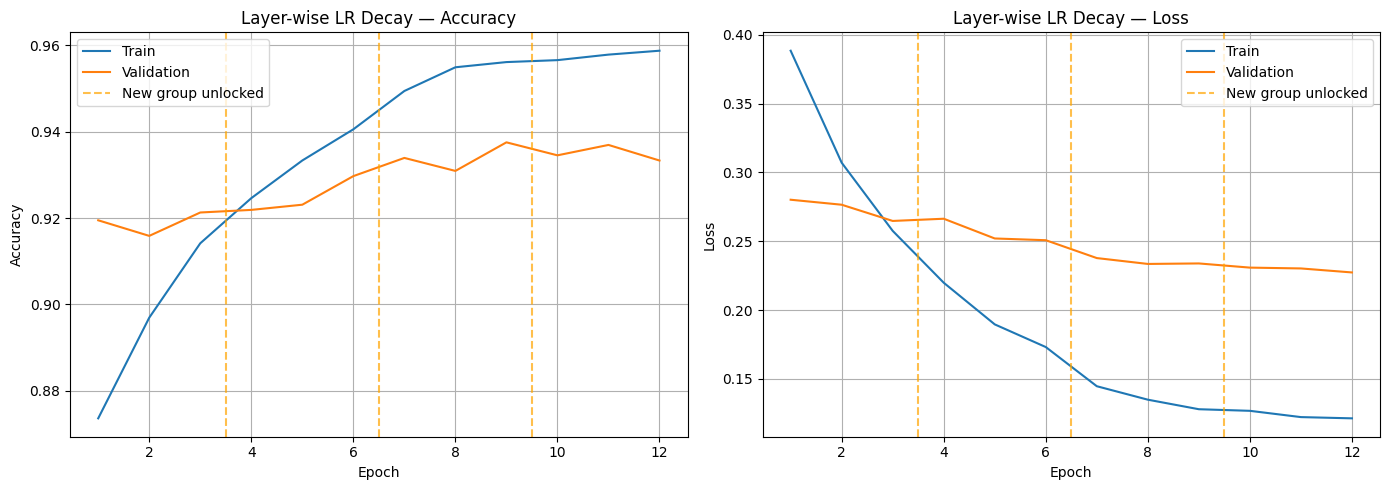

🏃 View run Exp4_Artifacts at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2/runs/0bc563f4526f46c08ead2d6d49dea159
🧪 View experiment at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2


In [28]:
all_acc_lw      = sum([h.history["accuracy"]     for h in all_history_lwlr], [])
all_val_acc_lw  = sum([h.history["val_accuracy"] for h in all_history_lwlr], [])
all_loss_lw     = sum([h.history["loss"]         for h in all_history_lwlr], [])
all_val_loss_lw = sum([h.history["val_loss"]     for h in all_history_lwlr], [])
epochs_lw       = range(1, len(all_acc_lw) + 1)

boundaries_lw = []
offset = 0
for h in all_history_lwlr[:-1]:
    offset += len(h.history["accuracy"])
    boundaries_lw.append(offset)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, train, val, ylabel in zip(
    axes,
    [all_acc_lw, all_loss_lw],
    [all_val_acc_lw, all_val_loss_lw],
    ["Accuracy", "Loss"]
):
    ax.plot(epochs_lw, train, label="Train")
    ax.plot(epochs_lw, val,   label="Validation")
    for i, b in enumerate(boundaries_lw):
        ax.axvline(x=b + 0.5, color="orange", linestyle="--", alpha=0.7,
                   label="New group unlocked" if i == 0 else "")
    ax.set_title(f"Layer-wise LR Decay — {ylabel}")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True)

plt.tight_layout()
lwlr_curve_path = "results/layerwise_lr_curves.png"
plt.savefig(lwlr_curve_path, dpi=150); plt.show()

# Log curve
with mlflow.start_run(run_name="Exp4_Artifacts"):
    mlflow.log_artifact(lwlr_curve_path)

### Experiment 4


| Metric | Value |
|--------|-------|
| Test Accuracy | **91.29%** |
| Test Loss | **0.2947** |

**Analysis:**
- Additional layer groups were unfrozen progressively while the learning rate was reduced at each round.
- This produced the strongest result in the project, with **91.29%** test accuracy and **0.2947** test loss.
- The method improved slightly over gradual unfreezing and standard fine-tuning.
- The training process remained stable  and the validation curves  good convergence with limited overfitting.
- layer-wise learning rate decay was the most effective transfer learning strategy for this dataset.

## Experiment Comparison

In [ ]:
comparison = pd.DataFrame({
    "Experiment": [
        "1 — Feature Extraction",
        "2 — Fine-Tuning",
        "3 — Gradual Unfreezing",
        "4 — Layer-wise LR Decay",
    ],
    "Test Accuracy": [
        results_fe["test_acc"], results_ft["test_acc"],
        results_gu["test_acc"], results_lwlr["test_acc"],
    ],
    "Test Loss": [
        results_fe["test_loss"], results_ft["test_loss"],
        results_gu["test_loss"], results_lwlr["test_loss"],
    ],
    "Strategy": [
        "Frozen base", "Last 20 layers", "Block-by-block", "Decayed LR per group"
    ],
})

comparison.to_csv("results/comparison.csv", index=False)
comparison

,Experiment,Test Accuracy,Test Loss,Strategy
0,1 — Feature Extraction,0.8877,0.3512,Frozen base
1,2 — Fine-Tuning,0.9021,0.3110,Last 20 layers
2,3 — Gradual Unfreezing,0.9099,0.3005,Block-by-block
3,4 — Layer-wise LR Decay,0.9129,0.2947,Decayed LR per group


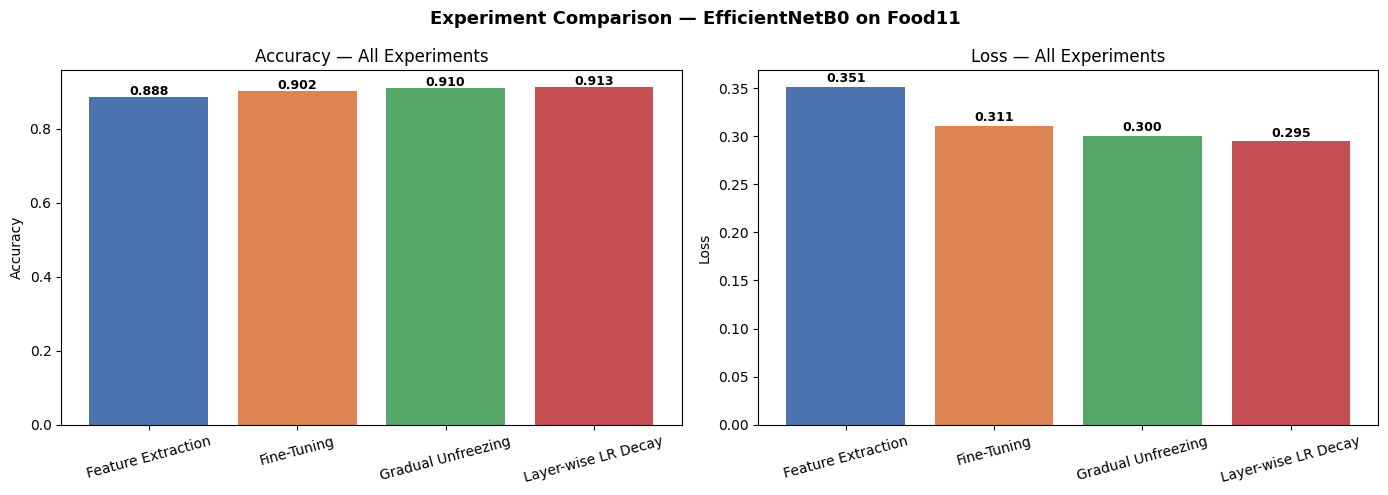

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
labels = [e.split("—")[1].strip() for e in comparison["Experiment"]]

for ax, metric, ylabel in zip(
    axes,
    ["Test Accuracy", "Test Loss"],
    ["Accuracy", "Loss"]
):
    bars = ax.bar(labels, comparison[metric], color=colors)
    ax.set_title(f"{ylabel} — All Experiments")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", fontweight="bold", fontsize=9)

plt.suptitle("Experiment Comparison — EfficientNetB0 on Food11",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/comparison_chart.png", dpi=150)
plt.show()

In [32]:
with mlflow.start_run(run_name="All_Experiments_Comparison"):
    mlflow.log_artifact("results/comparison.csv")
    mlflow.log_artifact("results/comparison_chart.png")
    mlflow.log_metrics({
        "fe_test_accuracy":   results_fe["test_acc"],
        "ft_test_accuracy":   results_ft["test_acc"],
        "gu_test_accuracy":   results_gu["test_acc"],
        "lwlr_test_accuracy": results_lwlr["test_acc"],
    })

🏃 View run All_Experiments_Comparison at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2/runs/ec0f1ee31b604b64b210d6085796b948
🧪 View experiment at: https://dagshub.com/MoojProject/efficientnet-food.mlflow/#/experiments/2


## Save Best Model

In [33]:
all_results = {
    "Feature Extraction":    (results_fe,   "models/feature_extraction_best-2.keras"),
    "Fine-Tuning":           (results_ft,   "models/fine_tuned_best.keras"),
    "Gradual Unfreezing":    (results_gu,   "models/exp3_gradual_unfreezing.keras"),
    "Layer-wise LR Decay":   (results_lwlr, "models/exp4_layerwise_lr.keras"),
}

best_name = max(all_results, key=lambda k: all_results[k][0]["test_acc"])
best_res, best_path = all_results[best_name]

summary = {
    "best_experiment": best_name,
    "best_model_path": best_path,
    "results": {
        name: {"test_accuracy": round(float(r["test_acc"]), 4),
               "test_loss":     round(float(r["test_loss"]), 4)}
        for name, (r, _) in all_results.items()
    }
}

with open("results/final_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print(json.dumps(summary, indent=4))

{
    "best_experiment": "Layer-wise LR Decay",
    "best_model_path": "models/exp4_layerwise_lr.keras",
    "results": {
        "Feature Extraction": {
            "test_accuracy": 0.8877,
            "test_loss": 0.3512
        },
        "Fine-Tuning": {
            "test_accuracy": 0.9021,
            "test_loss": 0.311
        },
        "Gradual Unfreezing": {
            "test_accuracy": 0.9099,
            "test_loss": 0.3005
        },
        "Layer-wise LR Decay": {
            "test_accuracy": 0.9129,
            "test_loss": 0.2947
        }
    }
}


## Method Comparison

| Aspect | Feature Extraction | Fine-Tuning | Gradual Unfreezing | Layer-wise LR Decay |
|---|---|---|---|---|
| Trainable layers | Classification head only | Last 20 backbone layers | Backbone unlocked in phases | Layer groups unlocked progressively |
| Learning rate | `1e-3` | `1e-5` | `1e-5` per phase | Decayed across groups |
| Test Accuracy | 88.77% | 90.21% | 90.99% | **91.29%** |
| Test Loss | 0.3512 | 0.3110 | 0.3005 | **0.2947** |
| Convergence | Fast | Stable, slower | Smooth and phased | Smoothest and most controlled |
| Overfitting risk | Low | Moderate | Moderate | Low |
| Catastrophic forgetting risk | Very low | Moderate | Low | Very low |
| Training complexity | Simple | Simple | Medium | Medium |

## Key Observations

1. **Feature Extraction** provided a strong and efficient baseline.  
   Only the classification head was trained, so the method was simple, fast, and low-risk. It achieved solid performance with minimal tuning.

2. **Fine-Tuning** improved performance by adapting the last pretrained layers to Food11.  
   This required a much smaller learning rate (`1e-5`) and careful handling of BatchNormalization behavior during training, as recommended in the Keras transfer learning guide. :contentReference[oaicite:0]{index=0}

3. **Gradual Unfreezing** produced smoother adaptation than standard fine-tuning.  
   Unlocking the backbone in phases reduced the optimization shock that can happen when many pretrained layers are made trainable at once. This led to better generalization and improved test performance.

4. **Layer-wise LR Decay** achieved the best overall result.  
   Progressively unlocking groups while reducing the learning rate gave the model finer control over adaptation. Earlier layers, which usually encode more general visual features, were updated more conservatively, while deeper layers adapted more to the Food11 domain. This experiment achieved the highest test accuracy and lowest test loss.

## Generalization and Overfitting

- All experiments showed relatively small train–validation gaps, which  good generalization .
- **Feature Extraction** had the lowest overfitting risk because the pretrained EfficientNet backbone remained frozen.
- **Fine-Tuning** improved accuracy, but it also had the highest risk of overfitting if training continued too long or the learning rate was too large.
- **Gradual Unfreezing** and **Layer-wise LR Decay** acted as more controlled fine-tuning strategies, improving adaptation while reducing instability.
- In the final comparison, more gradual and better-controlled adaptation consistently produced better test results than a single-step fine-tuning approach.

## Implementation Notes

- EfficientNet in Keras includes its own input preprocessing as part of the model, and it expects float pixel values in the `[0, 255]` range. :contentReference[oaicite:1]{index=1}
- Keras recommends using a very low learning rate for fine-tuning and keeping BatchNormalization behavior stable when unfreezing pretrained models. :contentReference[oaicite:2]{index=2}
- All experiments were tracked with MLflow, which supports logging parameters, metrics, code versions, and output artifacts for experiment comparison. :contentReference[oaicite:3]{index=3}
